# Training eines Klassifikationsmodells mit den Daten

## Abschnitt 1

Dieser Abschnitt führt den nächsten Verarbeitungsschritt der Klassifikationspipeline aus. Die Kommentare im Code erläutern die wichtigsten Verarbeitungsschritte.


In [ ]:
# Ausführung dieses Verarbeitungsschritts
# Dieser Codeabschnitt führt den folgenden Verarbeitungsschritt aus.
import spacy
import random
from spacy.training import Example
from spacy.util import minibatch
import json
import re
import pandas as pd
import numpy as np
# Trainings- und Testdaten erzeugen
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Logistic-Regression-Modell definieren
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report
# Random-Forest-Modell definieren
from sklearn.ensemble import RandomForestClassifier
# Kreuzvalidierung durchführen
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
# Konfusionsmatrix berechnen
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib


## Abschnitt 2

Dieser Abschnitt führt den nächsten Verarbeitungsschritt der Klassifikationspipeline aus. Die Kommentare im Code erläutern die wichtigsten Verarbeitungsschritte.


In [ ]:
# Ausführung dieses Verarbeitungsschritts
# Dieser Codeabschnitt führt den folgenden Verarbeitungsschritt aus.
nlp = spacy.load("../models/my_ner_model")


## Abschnitt 3

Dieser Abschnitt führt den nächsten Verarbeitungsschritt der Klassifikationspipeline aus. Die Kommentare im Code erläutern die wichtigsten Verarbeitungsschritte.


In [37]:
# Ausführung dieses Verarbeitungsschritts
# Dieser Codeabschnitt führt den folgenden Verarbeitungsschritt aus.
NERS = [
    "ENGINE",
    "PERFORMANCE",
    "HANDLING",
    "BUILD_QUALITY",

    "COMFORT",
    "SEAT",
    "SPACE",

    "SERVICE",
    "REPAIR",
    "SPARE_PART",

    "BATTERY",
    "RANGE",
    "CHARGING",
    "FUEL_CONSUMPTION",

    "PRICE",
    "VALUE_FOR_MONEY",

    "SAFETY",
    "AIRBAG",
    "ADAS",

    "DESIGN",
    "INTERIOR",
    "FEATURE",

    "PROBLEM"
]


## Abschnitt 4

Dieser Abschnitt führt den nächsten Verarbeitungsschritt der Klassifikationspipeline aus. Die Kommentare im Code erläutern die wichtigsten Verarbeitungsschritte.


In [38]:
# Ausführung dieses Verarbeitungsschritts
# Dieser Codeabschnitt führt den folgenden Verarbeitungsschritt aus.
Aspects=[
'performance-quality',
'comfort',
'service',
'battery-fuel consumption',
'price',
'safety',
'design-features',
]


## Abschnitt 5

Dieser Abschnitt führt den nächsten Verarbeitungsschritt der Klassifikationspipeline aus. Die Kommentare im Code erläutern die wichtigsten Verarbeitungsschritte.


In [39]:
# Ausführung dieses Verarbeitungsschritts
# Dieser Codeabschnitt führt den folgenden Verarbeitungsschritt aus.
with open("../data/cars_reviews_labeled.json", "r", encoding="utf-8") as file:
    data = json.load(file)

doc = nlp(data[2]["Comment"])
spacy.displacy.render(doc, style='ent')


## Abschnitt 6

Dieser Abschnitt führt den nächsten Verarbeitungsschritt der Klassifikationspipeline aus. Die Kommentare im Code erläutern die wichtigsten Verarbeitungsschritte.


In [40]:
# Ausführung dieses Verarbeitungsschritts
# Dieser Codeabschnitt führt den folgenden Verarbeitungsschritt aus.
dfs = []

for i, j_data in enumerate(data):
    doc = nlp("TITLE:\n" + j_data["Title"] + "\n\n" +"TEXT:\n"+j_data["Comment"])

    df = pd.DataFrame(
        [(ent.text, ent.label_) for ent in doc.ents],
        columns=["Entität", "Typ"]
    )

    dfs.append(df)


## Abschnitt 7

Dieser Abschnitt führt den nächsten Verarbeitungsschritt der Klassifikationspipeline aus. Die Kommentare im Code erläutern die wichtigsten Verarbeitungsschritte.


In [41]:
# Ausführung dieses Verarbeitungsschritts
# Dieser Codeabschnitt führt den folgenden Verarbeitungsschritt aus.
dfs[10]


,Entität,Typ
0,lag,PROBLEM
1,power,PERFORMANCE
2,steering,HANDLING
3,brakes,HANDLING
4,features,FEATURE
5,Interiors,INTERIOR
6,infotainment,INTERIOR
7,safest,SAFETY
8,EV battery,BATTERY
9,NCAP,SAFETY


## Abschnitt 8

Dieser Abschnitt führt den nächsten Verarbeitungsschritt der Klassifikationspipeline aus. Die Kommentare im Code erläutern die wichtigsten Verarbeitungsschritte.


In [42]:
# Ausführung dieses Verarbeitungsschritts
# Dieser Codeabschnitt führt den folgenden Verarbeitungsschritt aus.
ner_count = np.zeros((len(dfs), len(NERS)), dtype=int)

for i, df in enumerate(dfs):
    for j, ner in enumerate(NERS):
        ner_count[i, j] = (df["Typ"] == ner).sum()

print(ner_count)


[[0 1 0 ... 1 1 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 3 0 ... 0 1 0]
 [1 1 1 ... 3 2 0]]


## Abschnitt 9

Dieser Abschnitt führt den nächsten Verarbeitungsschritt der Klassifikationspipeline aus. Die Kommentare im Code erläutern die wichtigsten Verarbeitungsschritte.


In [43]:
# Ausführung dieses Verarbeitungsschritts
# Dieser Codeabschnitt führt den folgenden Verarbeitungsschritt aus.
print(ner_count[2])


[0 0 0 0 0 0 0 0 0 0 6 4 2 0 0 0 0 0 0 0 0 0 0]


## Abschnitt 10

Dieser Abschnitt führt den nächsten Verarbeitungsschritt der Klassifikationspipeline aus. Die Kommentare im Code erläutern die wichtigsten Verarbeitungsschritte.


In [44]:
# Ausführung dieses Verarbeitungsschritts
# Dieser Codeabschnitt führt den folgenden Verarbeitungsschritt aus.
data_lable =np.zeros(len(dfs))
for j, j_data in enumerate(data):
    for i ,a_cls in enumerate(Aspects):
       if j_data["aspect"] ==a_cls:
           data_lable[j]=i


## Abschnitt 11

Dieser Abschnitt führt den nächsten Verarbeitungsschritt der Klassifikationspipeline aus. Die Kommentare im Code erläutern die wichtigsten Verarbeitungsschritte.


In [27]:
# Ausführung dieses Verarbeitungsschritts
# Dieser Codeabschnitt führt den folgenden Verarbeitungsschritt aus.
X = ner_count
y = data_lable


## Abschnitt 12

Dieser Abschnitt führt den nächsten Verarbeitungsschritt der Klassifikationspipeline aus. Die Kommentare im Code erläutern die wichtigsten Verarbeitungsschritte.


In [28]:
# Ausführung dieses Verarbeitungsschritts
# Dieser Codeabschnitt führt den folgenden Verarbeitungsschritt aus.
unique, counts = np.unique(y, return_counts=True)

for cls, count in zip(unique, counts):
    print(cls, count)


0.0 8
1.0 25
2.0 52
3.0 31
4.0 29
5.0 16
6.0 13


## Abschnitt 13

Dieser Abschnitt führt den nächsten Verarbeitungsschritt der Klassifikationspipeline aus. Die Kommentare im Code erläutern die wichtigsten Verarbeitungsschritte.


In [54]:
# Ausführung dieses Verarbeitungsschritts
# Dieser Codeabschnitt führt den folgenden Verarbeitungsschritt aus.
model_scores = {}
cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)


models = {

    "SVC": Pipeline([
        ("scaler", StandardScaler()),
# Support-Vector-Classifier definieren
        ("classifier", SVC(class_weight="balanced"))
    ]),

# Random-Forest-Modell definieren
    "RandomForest": RandomForestClassifier(
        class_weight="balanced",
        n_estimators=500,
        random_state=30
    ),
# Logistic-Regression-Modell definieren
    "LogisticRegression":Pipeline([
    ("scaler", StandardScaler()),
# Logistic-Regression-Modell definieren
    ("classifier", LogisticRegression(
        max_iter=1000,
        C=2.0,
    ))
])
}

for name, clf in models.items():

# Kreuzvalidierung durchführen
    scores = cross_val_score(
        clf,
        X,
        y,
        cv=cv,

    )
    model_scores[name] = scores.mean()
    print(name)
    print("Scores:", scores)
    print("Mean Macro F1:", scores.mean())
    print("---------------------")


SVC
Scores: [0.5        0.45454545 0.44186047 0.51162791]
Mean Macro F1: 0.47700845665961944
---------------------
RandomForest
Scores: [0.70454545 0.65909091 0.62790698 0.60465116]
Mean Macro F1: 0.6490486257928119
---------------------
LogisticRegression
Scores: [0.59090909 0.63636364 0.58139535 0.62790698]
Mean Macro F1: 0.6091437632135306
---------------------


## Abschnitt 14

Dieser Abschnitt führt den nächsten Verarbeitungsschritt der Klassifikationspipeline aus. Die Kommentare im Code erläutern die wichtigsten Verarbeitungsschritte.


In [55]:
# Ausführung dieses Verarbeitungsschritts
# Dieser Codeabschnitt führt den folgenden Verarbeitungsschritt aus.
# Random-Forest-Modell definieren


best_model_name = max(model_scores, key=model_scores.get)
best_model = models[best_model_name]

print("Best model:", best_model_name)
print("Best Macro F1:", model_scores[best_model_name])
# Modell trainieren
best_model.fit(X, y)
y_pred = cross_val_predict(
    best_model,
    X,
    y,
    cv=cv,
)


Best model: RandomForest
Best Macro F1: 0.6490486257928119


## Abschnitt 15

Dieser Abschnitt führt den nächsten Verarbeitungsschritt der Klassifikationspipeline aus. Die Kommentare im Code erläutern die wichtigsten Verarbeitungsschritte.


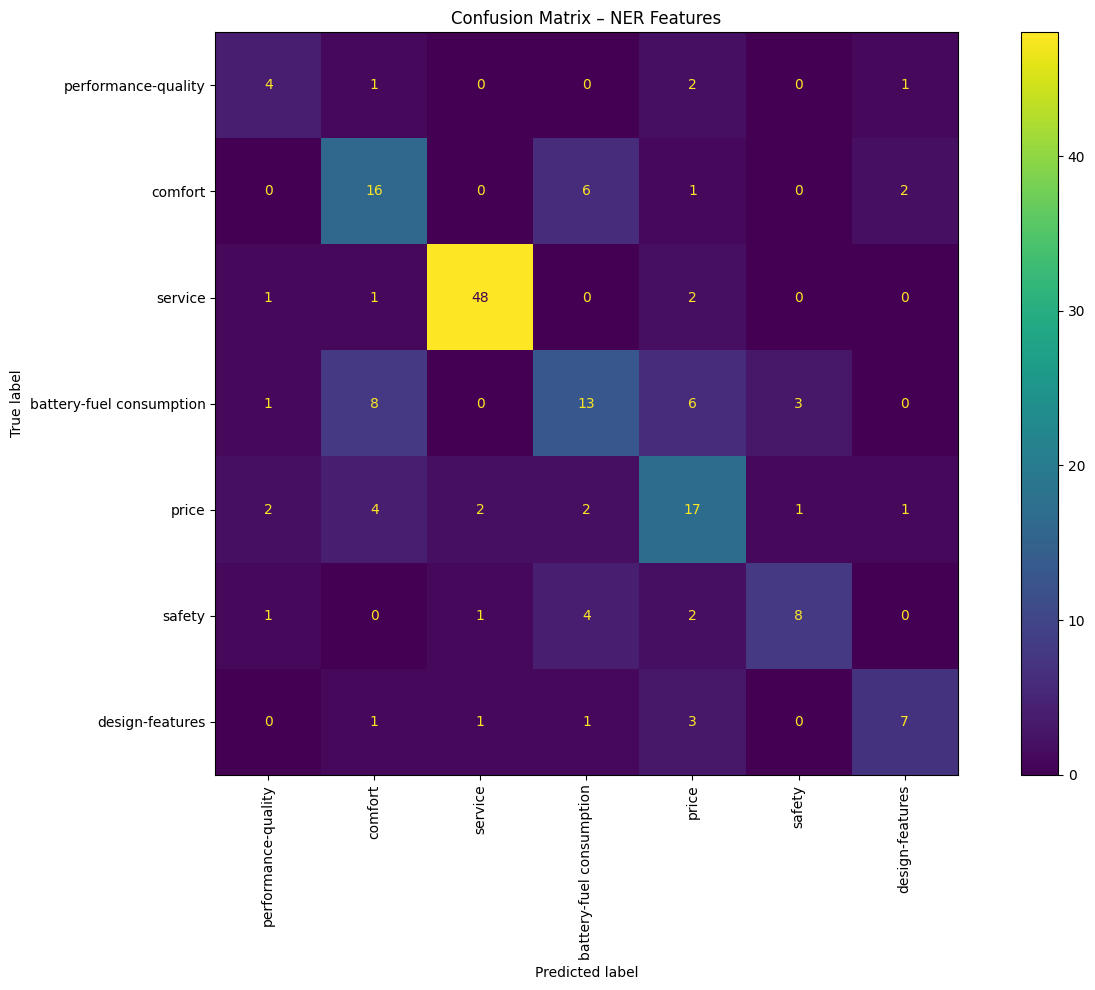

In [56]:
# Ausführung dieses Verarbeitungsschritts
# Dieser Codeabschnitt führt den folgenden Verarbeitungsschritt aus.
# Konfusionsmatrix berechnen
cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(
# Konfusionsmatrix berechnen
    confusion_matrix=cm,
    display_labels=Aspects
)

fig, ax = plt.subplots(figsize=(14, 10))

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)

plt.title("Confusion Matrix – NER Features")
plt.tight_layout()
plt.show()


## Abschnitt 16

Dieser Abschnitt führt den nächsten Verarbeitungsschritt der Klassifikationspipeline aus. Die Kommentare im Code erläutern die wichtigsten Verarbeitungsschritte.


In [34]:
# Ausführung dieses Verarbeitungsschritts
# Dieser Codeabschnitt führt den folgenden Verarbeitungsschritt aus.
# Trainiertes Modell speichern
joblib.dump(best_model, "../models/car_reviews_classifier.pkl")
# Trainiertes Modell speichern
joblib.dump(Aspects, "../models/class_names.pkl")
# Trainiertes Modell speichern
joblib.dump(NERS, "../models/ner_names.pkl")


['../models/ner_names.pkl']